<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/mnistdata_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The **MNIST** database (Modified National Institute of Standards and Technology) is a foundational dataset for machine learning, featuring 70,000 grayscale pixel images of handwritten digits (0–9). Widely regarded as the "hello world" of computer vision, it contains 60,000 training and 10,000 testing images used for benchmarking classification systems.

In [ ]:
# Import the library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from matplotlib import pyplot as plt

# Load MNIST Dataset from keras

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
print(x_test.shape)
print(y_test.shape)
print(x_train.shape)
print(y_train.shape)


(10000, 28, 28)
(10000,)
(60000, 28, 28)
(60000,)
[5 0 4 ... 5 6 8]


In [ ]:
# Normalize pixel values from [0, 255] → [0.0, 1.0]
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

print(f"Before normalization: min={x_train.min()}, max={x_train.max()}")
print(f"After  normalization: min={x_train_norm.min():.1f}, max={x_train_norm.max():.1f}")

# Flatten 28x28 images → 784-element vectors
# reshape(-1, 784) means: keep all images (-1), flatten each to 784 numbers
x_train_flat = x_train_norm.reshape(-1, 784)
x_test_flat  = x_test_norm.reshape(-1, 784)

print(f"\nShape before flattening: {x_train_norm.shape}")
print(f"Shape after  flattening: {x_train_flat.shape}")


Before normalization: min=0, max=255
After  normalization: min=0.0, max=1.0

Shape before flattening: (60000, 28, 28)
Shape after  flattening: (60000, 784)


In [ ]:
# Build the model
model = tf.keras.Sequential([
    # Layer 1: Input layer — accepts 784 numbers
    tf.keras.layers.Input(shape=(784,)),

    # Layer 2: First hidden layer — 128 neurons
    tf.keras.layers.Dense(128, activation='relu'),

    # Layer 3: Second hidden layer — 64 neurons
    tf.keras.layers.Dense(64, activation='relu'),

    # Layer 4: Output layer — 10 neurons (one per digit 0-9)
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
# Compile the model
# optimizer  → how the model updates its weights (Adam is a popular choice)
# loss       → how we measure mistakes (sparse_categorical means labels are integers 0-9)
# metrics    → what we want to track during training (accuracy)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print a summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
print(" Training started...\n")

history = model.fit(
    x_train_flat,   # Training images
    y_train,        # Correct labels
    epochs=10,      # Go through ALL training images 10 times
    batch_size=64,  # Process 64 images at a time
    validation_split=0.1,  # Use 10% of data for validation
    verbose=1       # Print progress after each epoch
)

print("\n Training complete!")

 Training started...

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9136 - loss: 0.3043 - val_accuracy: 0.9618 - val_loss: 0.1311
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9634 - loss: 0.1227 - val_accuracy: 0.9690 - val_loss: 0.1047
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9746 - loss: 0.0836 - val_accuracy: 0.9738 - val_loss: 0.0888
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9802 - loss: 0.0642 - val_accuracy: 0.9785 - val_loss: 0.0762
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9845 - loss: 0.0487 - val_accuracy: 0.9678 - val_loss: 0.1062
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9880 - loss: 0.0384 - val_accuracy: 0.9768 - val_loss: 0.0816
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9897 - loss: 0.0317 - val_accuracy: 0.9780 - val_loss: 0.0843
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9919 - loss: 0.0

In [ ]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)

print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"\n Our model correctly identifies {test_accuracy * 100:.1f}% of handwritten digits!")

Test Loss    : 0.0977
Test Accuracy: 97.54%

 Our model correctly identifies 97.5% of handwritten digits!


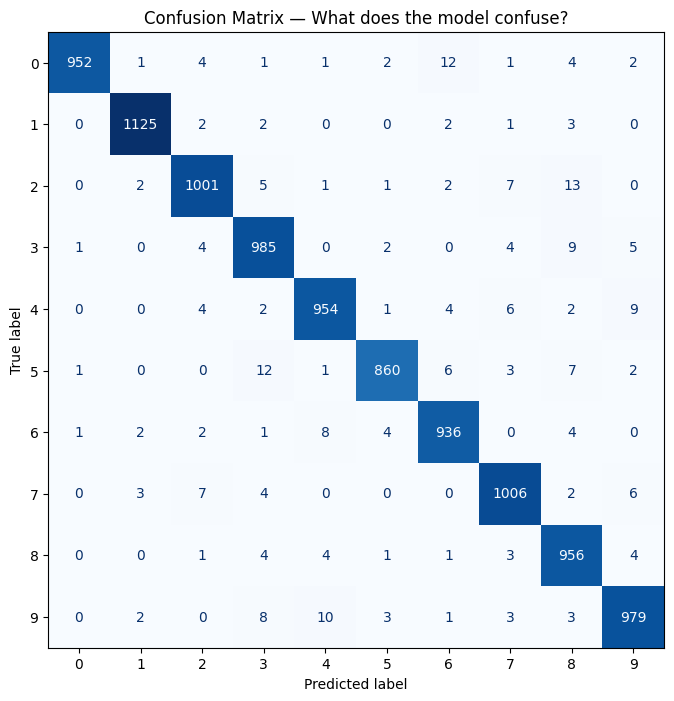

The diagonal cells (top-left to bottom-right) are CORRECT predictions.
Off-diagonal cells show mistakes — e.g., predicting '4' when the true label was '9'.


In [ ]:
# Confusion Matrix
# A confusion matrix shows which digits get confused with each other
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get model predictions for all test images
y_pred_probs = model.predict(x_test_flat, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)  # Pick the digit with highest probability

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — What does the model confuse?")
plt.show()

print("The diagonal cells (top-left to bottom-right) are CORRECT predictions.")
print("Off-diagonal cells show mistakes — e.g., predicting '4' when the true label was '9'.")



---



In [ ]:
# Save the model

# model.save('mnist_model.h5') # legacy method it is not recommeended

In [ ]:
# Saaving the model
model.save('my_model.keras')



---



In [ ]:
# Load the saved model

loaded_model = tf.keras.models.load_model('my_model.keras')

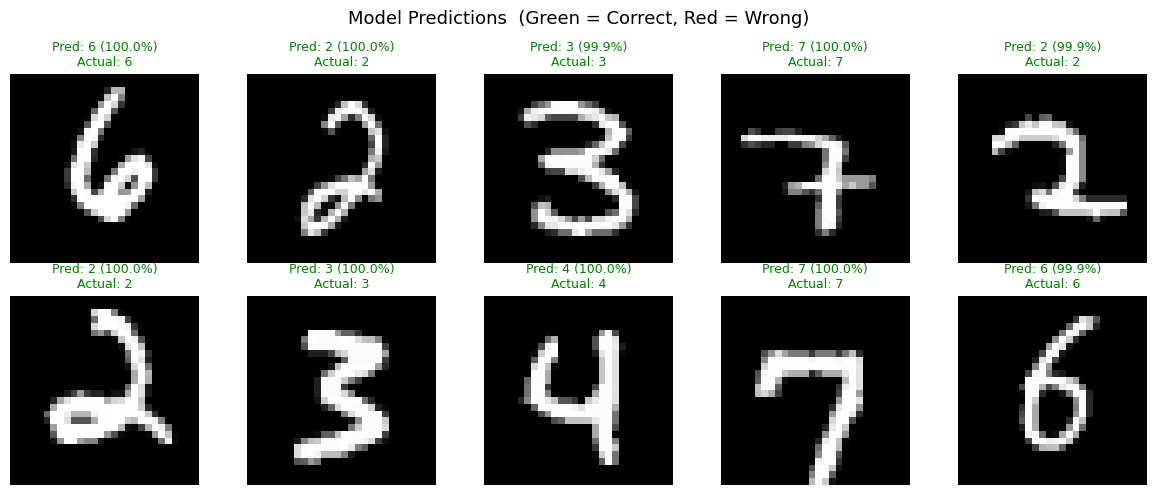

In [ ]:
# Predict on 10 random test images
np.random.seed(42)
random_indices = np.random.choice(len(x_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    # Get model output: an array of 10 probabilities (one per digit)
    probs     = loaded_model.predict(x_test_flat[idx:idx+1], verbose=0)[0]
    predicted = np.argmax(probs)    # Digit with highest probability
    actual    = y_test[idx]         # True label
    confidence = probs[predicted] * 100

    axes[i].imshow(x_test[idx], cmap='gray')
    color = 'green' if predicted == actual else 'red'
    axes[i].set_title(
        f"Pred: {predicted} ({confidence:.1f}%)\nActual: {actual}",
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Model Predictions  (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from PIL import Image, ImageOps

# 1. Define the filename
filename = '4.png'

# 2. Open the image
img = Image.open(filename).convert('L')

# 3. CRITICAL STEP: Invert colors if necessary
# MNIST digits are white on a black background.
# If your upload is black ink on white paper, you must invert it.
# img = ImageOps.invert(img)

# 4. Resize and Normalize
img = img.resize((28, 28))
img_array = np.array(img).astype('float32') / 255

# 5. Flatten to match the network input shape (1, 784)
img_array = img_array.reshape(1, 784)

# 6. Predict
predictions = loaded_model.predict(img_array)
predicted_class = np.argmax(predictions)

print(f"Uploaded image: {filename}")
print(f"Predicted digit: {predicted_class}")

FileNotFoundError: [Errno 2] No such file or directory: '4.png'

In [ ]:
import numpy as np
from PIL import Image
from google.colab import files

# Upload an image file
uploaded = files.upload()  # Prompts user to choose file

for filename in uploaded.keys():
    # Open the uploaded image
    img = Image.open(filename).convert('L').resize((28, 28))  # Grayscale, 28x28

    # Convert to numpy array and normalize
    img_array = np.array(img).astype('float32') / 255

    # Flatten to match the network input shape (1, 784)
    img_array = img_array.reshape(1, 28*28)

    # Predict using your trained model
    predictions = loaded_model.predict(img_array)
    predicted_class = np.argmax(predictions)

    print(f"Uploaded image: {filename}")
    print("Predicted digit:", predicted_class)



---



## Summary - What You Learned

| Step | What we did |
|------|-------------|
| 1 | Installed and imported Python libraries |
| 2 | Loaded the MNIST dataset (60k train + 10k test) |
| 3 | Visualized sample images and label distribution |
| 4 | Normalized pixels to [0,1] and flattened images |
| 5 | Built a 3-layer neural network |
| 6 | Trained the model for 10 epochs |
| 7 | Evaluated accuracy (~97%) and confusion matrix |
| 8 | Made predictions and visualized confidence |

---

## Challenge: Can You Do Better?

Try changing these things and see if accuracy improves:

```python
# 1. Add more neurons
tf.keras.layers.Dense(256, activation='relu'),

# 2. Add Dropout to prevent overfitting
tf.keras.layers.Dropout(0.2),

# 3. Train for more epochs
epochs=20

# 4. Try a different optimizer
optimizer='sgd'
```

For an even bigger jump, try a **Convolutional Neural Network (CNN)** — it's designed specifically for images and can reach **99%+ accuracy** on MNIST!

---

> **Great work!** We just built and trained our first neural network from scratch.